## Task 4h: Joining the Alcohol Abuse by State Dataset

In this task, we are integrating external data on **alcohol abuse rates by state** into our Haunted Places dataset. The alcohol abuse data was manually inputted into a CSV file. This allows us to explore whether there is a correlation between **alcohol consumption levels and reports of haunted places**.

### **Influence of this Dataset**
- **Potential Influence on Haunted Reports**:  
  - High alcohol consumption may **increase susceptibility to supernatural experiences** or misinterpretations of events.
  - States with higher alcohol abuse rates may report **a greater number of hauntings** due to impaired perception.
- **Geographic Analysis**:  
  - This dataset allows us to examine whether **certain states with higher alcohol abuse rates** also have a higher concentration of haunted locations.

### **How the Data is Merged**
- The **"state"** column in `haunted_places.tsv` is renamed to match the column name in the Alcohol Abuse dataset.
- We perform a **left join** to merge the data, ensuring all haunted locations remain in the dataset, even if no matching alcohol abuse data is found.
- Missing values in the alcohol abuse column will indicate that no data was available for that state.

### **Data Source & Processing**
- The **Alcohol Abuse by State dataset** was compiled from external sources and **manually entered** into a CSV file before integration.
- The dataset includes key metrics such as:
  - **Percentage of adults who binge drink**
  - **Alcohol-related deaths per 10,000 adults**
  - **Years of life lost due to alcohol-related deaths**
  - **Taxpayer cost of alcohol abuse per state**
- These variables provide additional context for analyzing **social or environmental factors influencing haunted place reports**.

By combining these datasets, we gain new insights into **how behavioral and societal factors may correlate with reports of paranormal activity**.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


In [21]:
haunted_places = pd.read_csv("../data/haunted_places.tsv", sep='\t')
alcohol_df = pd.read_csv('../data/alcohol_abuse_by_state.csv')

In [22]:
haunted_places = haunted_places.rename(columns={'state': 'State'})
combined_df = haunted_places.merge(alcohol_df, on='State', how='left')

In [23]:
combined_df.to_csv("../data/haunted_places.tsv", sep='\t', index=False)

## Data Processing: Adding Haunted Place Count to Alcohol Abuse Dataset  

This code **adds the number of haunted places per state** to the **Alcohol Abuse dataset** by standardizing state names, aggregating haunted place counts, and merging the data. It ensures that states with no haunted places are assigned a count of `0` and removes temporary columns created during merging. Finally, the updated dataset is saved for further analysis.  

In [24]:
# Standardize state names by stripping spaces to avoid merge issues
haunted_places["State"] = haunted_places["State"].str.strip()
alcohol_df["State"] = alcohol_df["State"].str.strip()

# Aggregate haunted places by state (count occurrences of each state)
haunted_count = haunted_places.groupby("State").size().reset_index(name="Haunted Place Count")

# Ensure "Haunted Place Count" exists in alcohol_df (set default 0)
alcohol_df["Haunted Place Count"] = 0  

# Merge the new count into the Alcohol Abuse dataset
alcohol_df = alcohol_df.merge(haunted_count, on="State", how="left", suffixes=("", "_new"))

# Replace the 0s with actual values from the merged data
alcohol_df["Haunted Place Count"] = alcohol_df["Haunted Place Count_new"].fillna(0).astype(int)

# Drop the temporary "_new" column used during merging
alcohol_df = alcohol_df.drop(columns=["Haunted Place Count_new"])

# Save the updated dataset
updated_file_path = "../data/alcohol_abuse_by_state.csv"
alcohol_df.to_csv(updated_file_path, index=False)

print("Haunted Place Count successfully added and saved to:", updated_file_path)


Haunted Place Count successfully added and saved to: ../data/alcohol_abuse_by_state.csv


In [25]:
# Checking to see that different column heading titles
print(haunted_places.columns)
print(alcohol_df.columns)

Index(['city', 'country', 'description', 'location', 'State', 'state_abbrev',
       'longitude', 'latitude', 'city_longitude', 'city_latitude',
       'Audio Evidence', 'Image/Video/Visual Evidence', 'Haunted Places Date',
       'Haunted Places Witness Count', 'Time of Day', 'Apparition Type',
       'Event Type', 'Deaths per Year',
       'Average Potential Life Years Lost per Death',
       'Deaths per 10,000 Adults',
       'Percentage of Adults who Binge Drink 1+ Times per Month',
       'Median Drinks per Binge', 'Top 25% Drinks per Binge',
       'Median Binge per Month', 'Top 25% Binge per Month',
       'Increase in Alcohol Deaths per Capita from 2015 to 2019',
       'Male Proportion of Deaths', 'Percent Deaths from Chronic Causes',
       'Percent Deaths from Acute Causes', 'Percent Deaths 35+',
       'Percent Deaths under 21', 'Years of Life Lost per Year',
       'Taxpayer Cost in 2010 (billions)',
       'Inflation Adjusted Cost to 2022 (billions)',
       'Inflation Ad

## Visualization #1: Haunted Places per State

This bar chart illustrates the **number of haunted places reported in each state** based on the dataset. It provides insights into which states have the most haunted locations

By visualizing the **distribution of haunted places**, we can explore whether certain states report **significantly more paranormal activity** than others. This visualization also sets the foundation for further analysis, such as **correlating hauntings with external factors** like information from the Alcohol Abuse Dataset. 

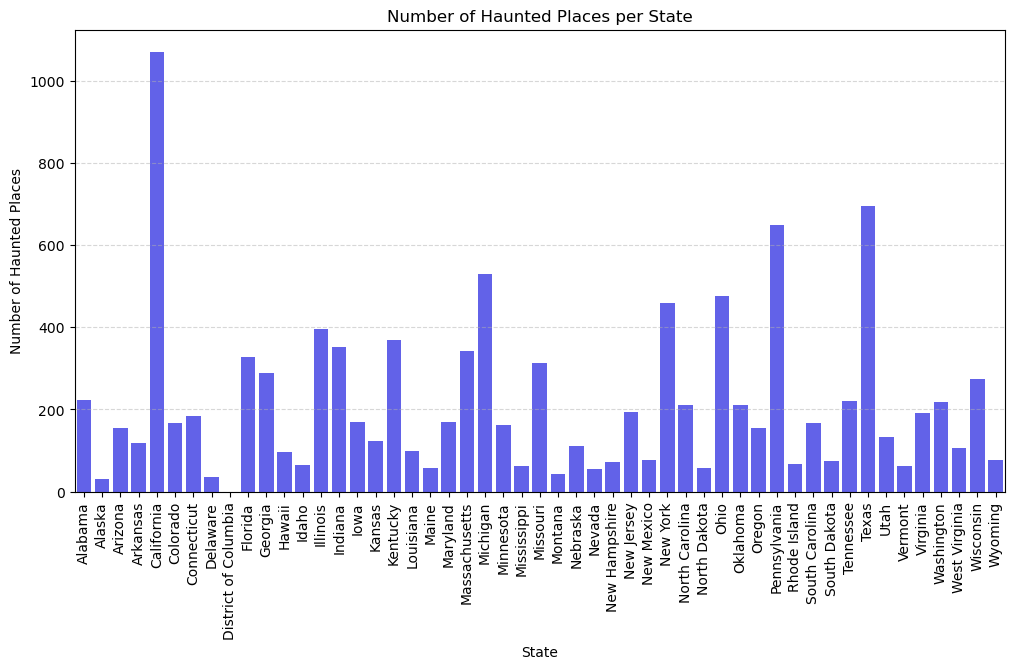

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(x=alcohol_df["State"], y=alcohol_df["Haunted Place Count"], color="blue", alpha=0.7)
plt.xticks(rotation=90)
plt.xlabel("State")
plt.ylabel("Number of Haunted Places")
plt.title("Number of Haunted Places per State")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Visualization #2: Haunted Places vs. Alcohol-Related Deaths per State  

This graph compares the **number of haunted places** in each state (bar chart) with **alcohol-related deaths per 10,000 adults** (line chart). It helps identify:  
- States with a **high number of reported hauntings**.  
- Whether states with **higher alcohol-related deaths** also have **more haunted place reports**.  

By visualizing these two metrics together, we can explore **potential correlations** between alcohol-related fatalities and the prevalence of haunted place reports. 


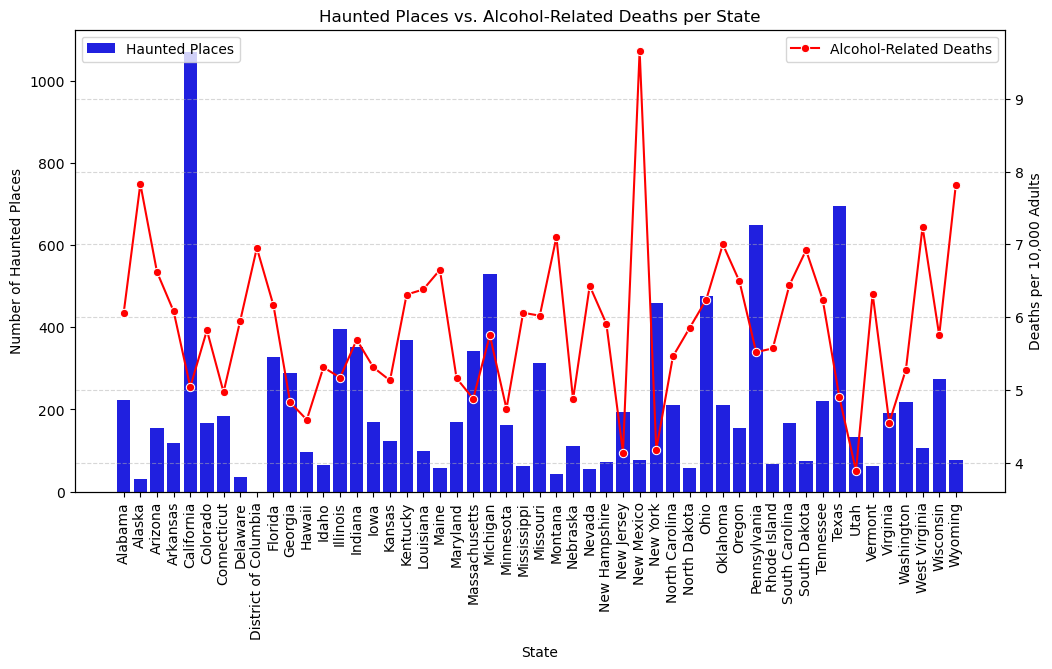

In [27]:
plt.figure(figsize=(12, 6))

# Create the bar chart for Haunted Places
ax = sns.barplot(x=alcohol_df["State"], y=alcohol_df["Haunted Place Count"], color="blue", label="Haunted Places")

# Create a secondary axis for Alcohol-Related Deaths
ax2 = ax.twinx()
sns.lineplot(x=alcohol_df["State"], y=alcohol_df["Deaths per 10,000 Adults"],
             ax=ax2, color="red", label="Alcohol-Related Deaths", marker="o")

# Set labels
ax.set_xlabel("State")
ax.set_ylabel("Number of Haunted Places")
ax2.set_ylabel("Deaths per 10,000 Adults")

# Fix the issue by setting ticks before labels
ax.set_xticks(range(len(alcohol_df["State"])))
ax.set_xticklabels(alcohol_df["State"], rotation=90)

# Legends and title
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("Haunted Places vs. Alcohol-Related Deaths per State")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()
